In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\RAJA\Desktop\Youtube Analytics Project\data\youtube.csv")

In [4]:
df.head()

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
0,0,UCU1_l0ZJyTK_7HZZ3Ruw8Dg,MAPS,pTnk3ziVVRM,2014-01-10T01:24:57.000Z,Psychedelic Horizons Beyond Psychotherapy Work...,Watch the full workshop at http://psychedelics...,29,Nonprofits & Activism,PT1H19M40S,4780,hd,False,1512,8.0,0.0,1.0
1,1,UCLuO2lUqHrPIIpx0hFenV2g,Tink Tink Club,cuJjSeHZIrg,2015-06-18T16:56:04.000Z,Episode 35 - Dr. James Fadiman,Dr. James Fadiman is the father of modern psyc...,22,People & Blogs,PT1H12M34S,4354,sd,False,881,14.0,0.0,3.0
2,2,UCihqrkaOgVMfLNo2W1hSliA,Podcast Bunk,IuyuZfWtGgg,2016-05-01T05:33:13.000Z,#325 Microdosing from The Adam and Dr Drew Sho...,Adam and Dr. Drew are solo today and they open...,22,People & Blogs,PT50M40S,3040,sd,False,67,0.0,1.0,3.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
4,4,UCFmLi6X1mojkFZOFngNR9tQ,Drug Education Agency,OpQIQEx7J5A,2014-08-15T10:53:58.000Z,Erschossener Kiffer / Drogen in Mikro-Dosierun...,"Von erschossenen ""Dealern"", von demonstrierend...",24,Entertainment,PT26M32S,1592,hd,False,5465,121.0,6.0,25.0


In [5]:
df.shape

(115, 17)

In [6]:
df.columns

Index(['Unnamed: 0', 'channelId', 'channelTitle', 'videoId', 'publishedAt',
       'videoTitle', 'videoDescription', 'videoCategoryId',
       'videoCategoryLabel', 'duration', 'durationSec', 'definition',
       'caption', 'viewCount', 'likeCount', 'dislikeCount', 'commentCount'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          115 non-null    int64  
 1   channelId           115 non-null    object 
 2   channelTitle        115 non-null    object 
 3   videoId             115 non-null    object 
 4   publishedAt         115 non-null    object 
 5   videoTitle          115 non-null    object 
 6   videoDescription    109 non-null    object 
 7   videoCategoryId     115 non-null    int64  
 8   videoCategoryLabel  115 non-null    object 
 9   duration            115 non-null    object 
 10  durationSec         115 non-null    int64  
 11  definition          115 non-null    object 
 12  caption             115 non-null    bool   
 13  viewCount           115 non-null    int64  
 14  likeCount           111 non-null    float64
 15  dislikeCount        111 non-null    float64
 16  commentC

In [8]:
df["publishedAt"]=pd.to_datetime(df["publishedAt"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   Unnamed: 0          115 non-null    int64              
 1   channelId           115 non-null    object             
 2   channelTitle        115 non-null    object             
 3   videoId             115 non-null    object             
 4   publishedAt         115 non-null    datetime64[ns, UTC]
 5   videoTitle          115 non-null    object             
 6   videoDescription    109 non-null    object             
 7   videoCategoryId     115 non-null    int64              
 8   videoCategoryLabel  115 non-null    object             
 9   duration            115 non-null    object             
 10  durationSec         115 non-null    int64              
 11  definition          115 non-null    object             
 12  caption             115 non-null    

In [10]:
df["publish_hour"]=df["publishedAt"].dt.hour

In [11]:
df[["publishedAt","publish_hour"]].head()

,publishedAt,publish_hour
0,2014-01-10 01:24:57+00:00,1
1,2015-06-18 16:56:04+00:00,16
2,2016-05-01 05:33:13+00:00,5
3,2016-01-25 04:48:22+00:00,4
4,2014-08-15 10:53:58+00:00,10


In [12]:
df.isnull().sum()

Unnamed: 0            0
channelId             0
channelTitle          0
videoId               0
publishedAt           0
videoTitle            0
videoDescription      6
videoCategoryId       0
videoCategoryLabel    0
duration              0
durationSec           0
definition            0
caption               0
viewCount             0
likeCount             4
dislikeCount          4
commentCount          2
publish_hour          0
dtype: int64

In [13]:
df["likeCount"]=df["likeCount"].fillna(0)
df["dislikeCount"]=df["dislikeCount"].fillna(0)
df["videoDescription"]=df["videoDescription"].fillna(0)
df["commentCount"]=df["commentCount"].fillna(0)

In [14]:
df.isnull().sum()

Unnamed: 0            0
channelId             0
channelTitle          0
videoId               0
publishedAt           0
videoTitle            0
videoDescription      0
videoCategoryId       0
videoCategoryLabel    0
duration              0
durationSec           0
definition            0
caption               0
viewCount             0
likeCount             0
dislikeCount          0
commentCount          0
publish_hour          0
dtype: int64

In [15]:
df.duplicated(subset="videoId").sum()

np.int64(0)

In [16]:
def video_length(sec):
    if sec <300:
        return "Short"
    elif sec<900:
        return "Medium"
    else:
        return "Long"
df["video_lenght"]=df["durationSec"].apply(video_length)

In [17]:
df.columns

Index(['Unnamed: 0', 'channelId', 'channelTitle', 'videoId', 'publishedAt',
       'videoTitle', 'videoDescription', 'videoCategoryId',
       'videoCategoryLabel', 'duration', 'durationSec', 'definition',
       'caption', 'viewCount', 'likeCount', 'dislikeCount', 'commentCount',
       'publish_hour', 'video_lenght'],
      dtype='object')

In [18]:
df[["durationSec","video_lenght"]].head()

,durationSec,video_lenght
0,4780,Long
1,4354,Long
2,3040,Long
3,1941,Long
4,1592,Long


In [19]:
df.groupby("videoCategoryLabel")["viewCount"].mean().sort_values(ascending=False)

videoCategoryLabel
News & Politics          27799.833333
Entertainment            23247.200000
Science & Technology     18291.466667
Education                 6513.750000
Film & Animation          4040.000000
Gaming                    1851.000000
Sports                    1805.000000
People & Blogs             962.720930
Travel & Events            843.000000
Comedy                     515.000000
Howto & Style              294.000000
Nonprofits & Activism      274.600000
Music                      125.000000
Name: viewCount, dtype: float64

In [20]:
df.groupby("video_lenght")["viewCount"].mean()

video_lenght
Long       2973.428571
Medium    28554.314286
Short       460.972603
Name: viewCount, dtype: float64

In [21]:
df.rename(columns={"video_lenght":"video_length"},inplace=True)

In [22]:
df.columns

Index(['Unnamed: 0', 'channelId', 'channelTitle', 'videoId', 'publishedAt',
       'videoTitle', 'videoDescription', 'videoCategoryId',
       'videoCategoryLabel', 'duration', 'durationSec', 'definition',
       'caption', 'viewCount', 'likeCount', 'dislikeCount', 'commentCount',
       'publish_hour', 'video_length'],
      dtype='object')

In [26]:
df.groupby("video_length")["viewCount"].mean().sort_values(ascending=False)

video_length
Medium    28554.314286
Long       2973.428571
Short       460.972603
Name: viewCount, dtype: float64

In [27]:
df.groupby("publish_hour")["viewCount"].mean().sort_values(ascending=False)

publish_hour
13    176728.333333
15     30462.400000
9      12993.166667
2      10464.000000
12      7695.375000
22      7057.750000
16      3124.900000
10      2734.000000
6       2061.285714
14      1544.777778
1       1512.000000
0       1343.250000
11      1109.750000
18       619.500000
7        606.714286
20       567.800000
8        490.666667
4        436.200000
21       376.000000
23       291.800000
17       263.000000
19       186.666667
3        132.000000
5        114.666667
Name: viewCount, dtype: float64

In [36]:
!pip install matplotlib

In [34]:
!pip install seaborn

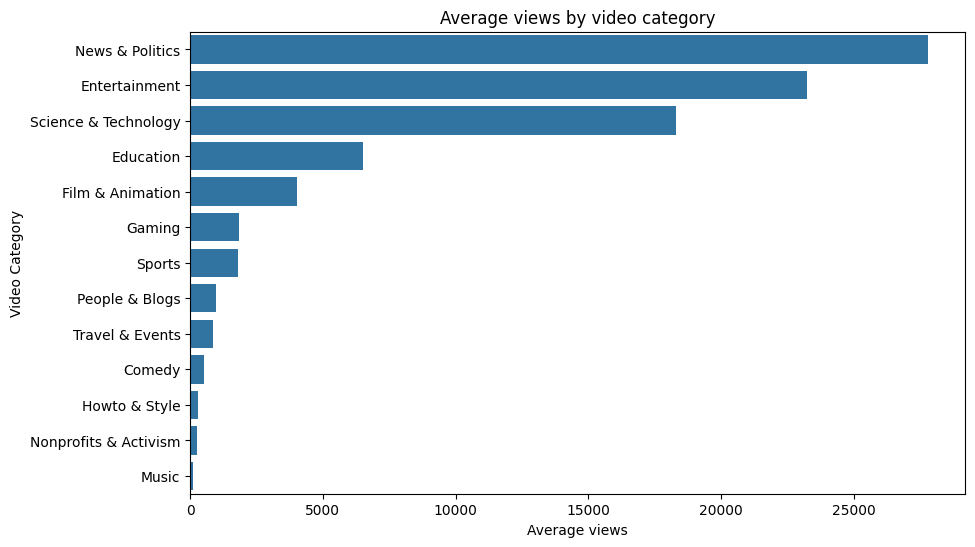

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
category_views=df.groupby("videoCategoryLabel")["viewCount"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=category_views.values,y=category_views.index)
plt.title("Average views by video category")
plt.xlabel("Average views")
plt.ylabel("Video Category")
plt.show()

In [47]:
df.to_csv("clean_youtube.csv",index=False)

In [48]:
top_videos = df.sort_values(by="viewCount", ascending=False).head(10)
top_videos[["videoTitle", "channelTitle", "viewCount"]]

,videoTitle,channelTitle,viewCount
9,Microdosing LSD or any Psychedelic,PsychedSubstance,526243
29,Mescaline Microdose,PsychedSubstance,148681
7,LSD: Microdosing & the SUPERNATURAL,Black Pigeon Speaks,108974
30,MICRODOSING MUSHROOMS : The Benefits of Microd...,The Natural Way of Healing,59255
33,Microdosing PSILOCYBIN Mushrooms Experiment | ...,Your Mate Tom,35928
23,'Microdosing' Psychedelic Drugs Has Positive E...,Secular Talk,28167
37,"What You Need To Know About ""Microdosing""",The Point with Ana Kasparian,27571
27,DMT Breakthrough / Micro dosing Method,Young Morpheus,18908
5,Microdosing Psilocybin Mushrooms & LSD - The O...,Oracle Frequency Podcast,12092
10,Microdosing PSILOCYBIN Mushrooms Experiment ||...,Your Mate Tom,8869


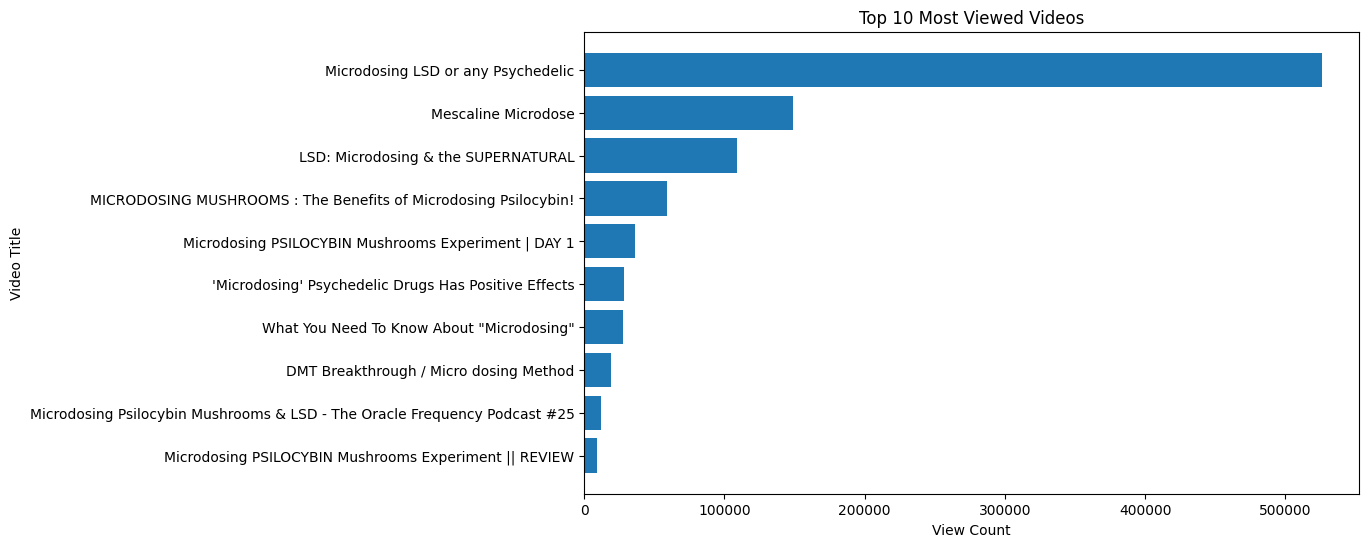

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_videos["videoTitle"], top_videos["viewCount"])
plt.xlabel("View Count")
plt.ylabel("Video Title")
plt.title("Top 10 Most Viewed Videos")
plt.gca().invert_yaxis()
plt.show()

In [51]:
df["engagement_rate"] = (df["likeCount"] + df["commentCount"]) / df["viewCount"]

In [52]:
df.groupby("videoCategoryLabel")["engagement_rate"].mean().sort_values(ascending=False)

videoCategoryLabel
Music                    0.048264
Entertainment            0.037004
News & Politics          0.030513
People & Blogs           0.026381
Travel & Events          0.023725
Education                0.019245
Film & Animation         0.012871
Gaming                   0.010805
Sports                   0.004432
Comedy                   0.003883
Nonprofits & Activism    0.003520
Science & Technology     0.002392
Howto & Style            0.000000
Name: engagement_rate, dtype: float64

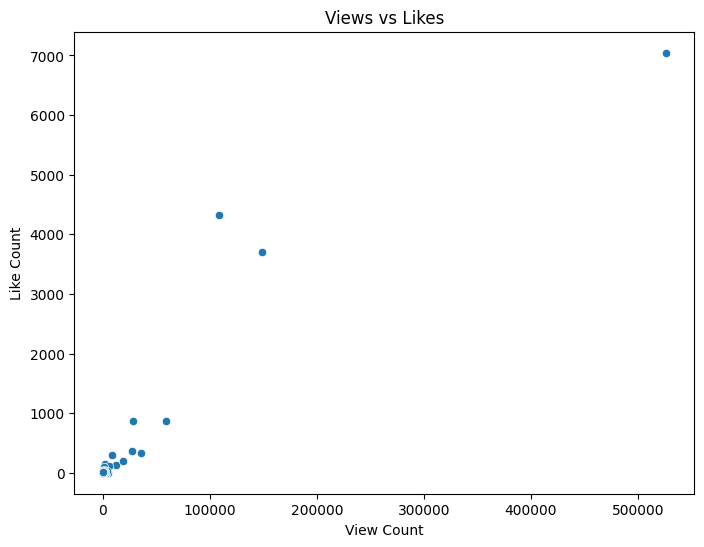

In [53]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["viewCount"], y=df["likeCount"])
plt.title("Views vs Likes")
plt.xlabel("View Count")
plt.ylabel("Like Count")
plt.show()

In [55]:
plt.savefig("category_views.png")

<Figure size 640x480 with 0 Axes>

In [56]:
df.to_csv("clean_youtube.csv", index=False)